<div align="center">

# Diagnóstico, Baselines e ARIMA/SARIMA
<hr>

### Séries Temporais, FGV EMAp - 2026/2 ###

Bryan Santos Monteiro<br>
João Vitor Tomaz Alves Ferreira<br>
Nicholas Costa<br>
Roger Vinícius Pereira Augusto<br>
Sofia Azeredo de Moura Monteiro<br>
Vinício Vasconcelos Muniz Deusdará

</div>

In [1]:
import matplotlib.pyplot as plt
from IPython.display import display

from src.dados import carregar_split, SERIES
from src.diagnostico import figura_diagnostico, resumo_zeros

In [6]:
treino, val = carregar_split()

# Confirmação que o split está sem vazamento
print('treino:', treino.index.min().date(), '-', treino.index.max().date(), f'({len(treino)} dias)')
print('validação:', val.index.min().date(), '-', val.index.max().date(), f'({len(val)} dias)')      
print('séries:', list(treino.columns))

assert treino.index.max() < val.index.min(), 'vazamento: treino invade a validação'

treino: 2011-01-29 - 2016-03-27 (1885 dias)
validação: 2016-03-28 - 2016-04-24 (28 dias)
séries: ['store_total', 'FOODS', 'HOBBIES']


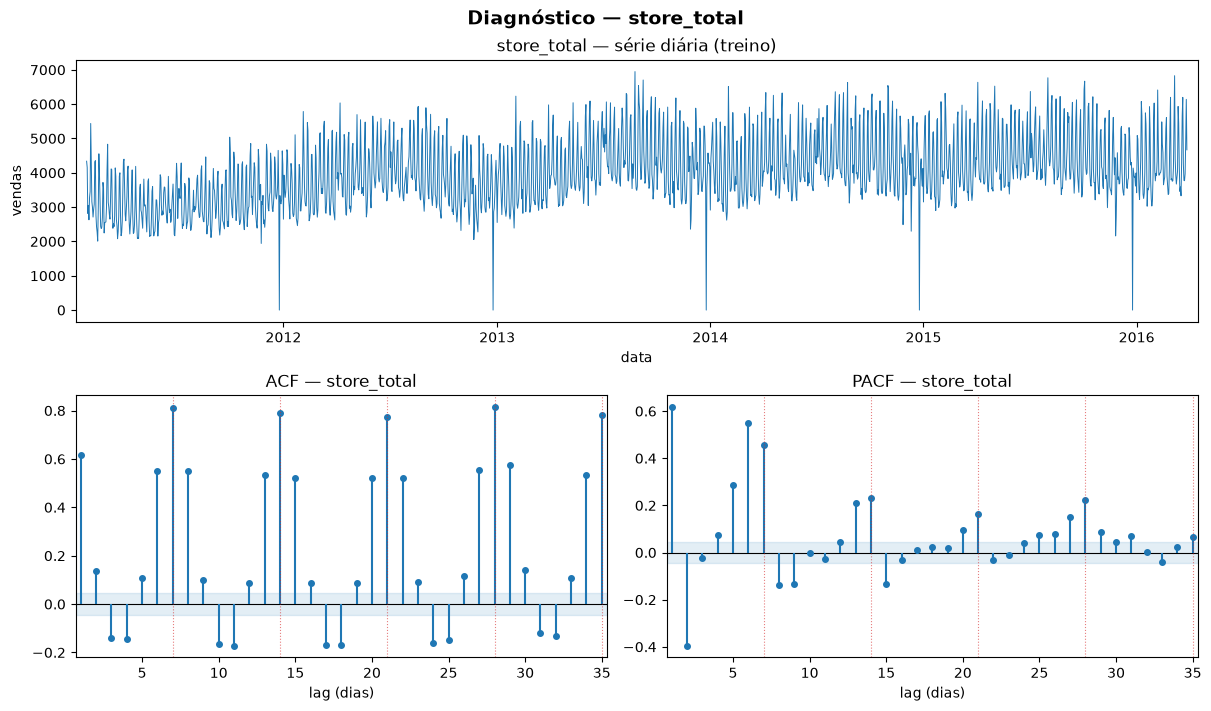

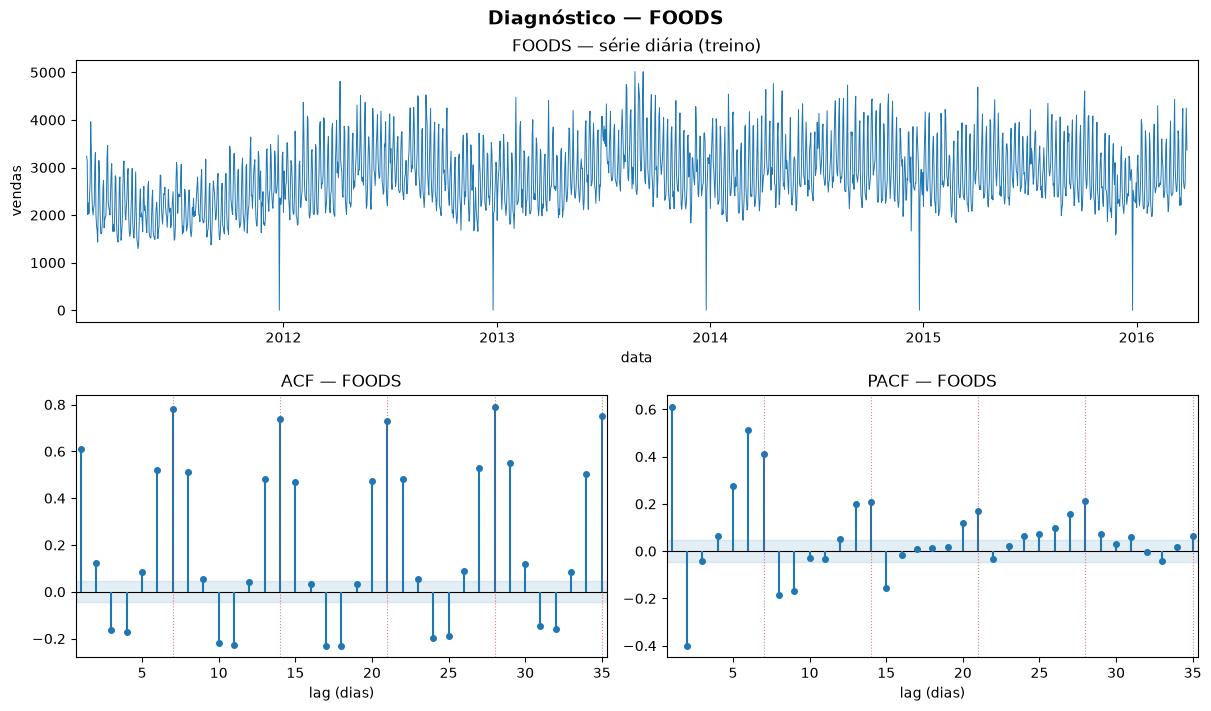

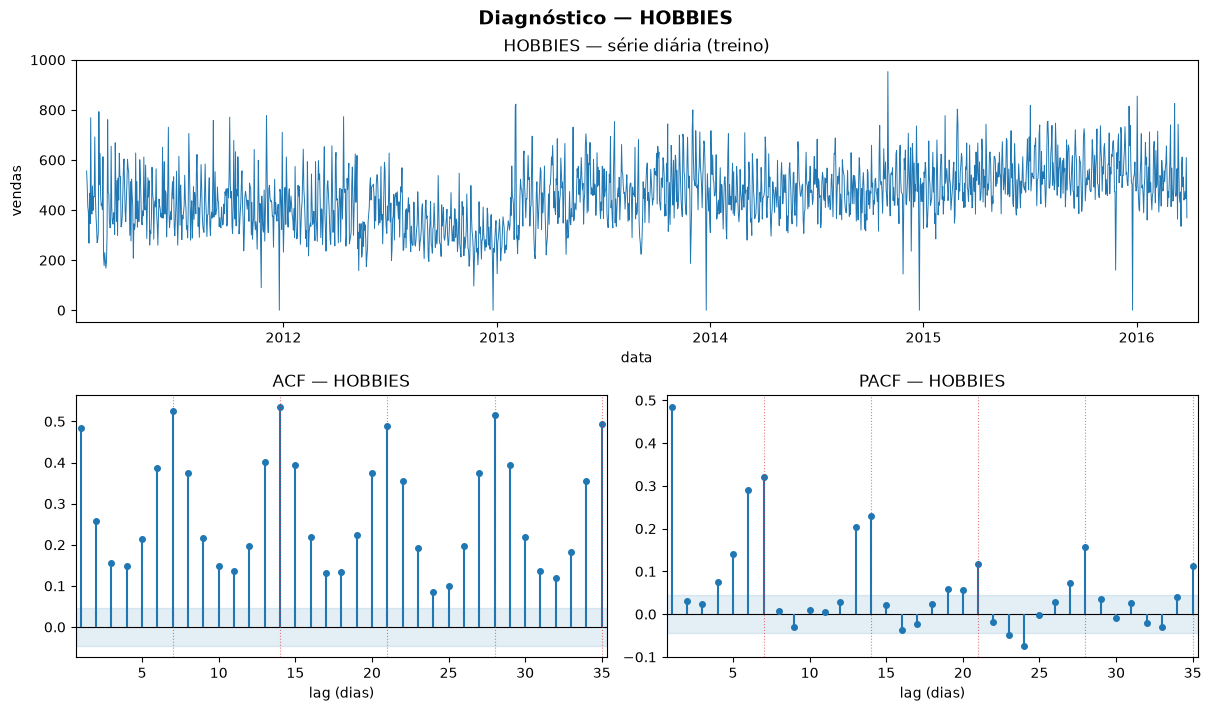

In [3]:
for s in SERIES:
    fig = figura_diagnostico(treino[s], s, salvar=f'figuras/diagnostico_{s}.png')
    display(fig)
    plt.close(fig)

Para cada série temos a série diária no tempo (em cima) e os correlogramas ACF e PACF (embaixo). Onde a faixa azul clara é a banda de ruído branco (±1,96/√n) e as linhas vermelhas pontilhadas marcam os múltiplos do período semanal (7, 14, 21, 28, 35).

In [ ]:
# Zeros de calendário (loja fechada)
display(resumo_zeros(treino))

,series,date,dia_semana
0,store_total,2011-12-25,Sunday
1,store_total,2012-12-25,Tuesday
2,store_total,2013-12-25,Wednesday
3,store_total,2014-12-25,Thursday
4,store_total,2015-12-25,Friday
5,FOODS,2011-12-25,Sunday
6,FOODS,2012-12-25,Tuesday
7,FOODS,2013-12-25,Wednesday
8,FOODS,2014-12-25,Thursday
9,FOODS,2015-12-25,Friday


## Comentário do diagnóstico

**Tendência.** `store_total` e `FOODS` têm tendência de alta de 2011 até cerca de 2013–2014 (pois a média anual de `store_total` sobe de ~3.1k para ~4.3k) e depois estabilizam num platô. `HOBBIES` não tem tendência monotônica clara: o nível cai até o fim de 2012 e dá um salto no início de 2013 (quebra de nível), ficando mais alto e levemente crescente daí em diante. Em todas as séries a média não é constante no tempo, o que, junto com o decaimento lento da ACF, indica não estacionaridade na média e a necessidade de uma diferença regular (d = 1) antes de modelar.

**Sazonalidade semanal (m = 7).** É um padrão forte das séries. O fim de semana fica ~40% acima do meio da semana, a segunda é elevada e ter–qua–qui formam o vale. Isso aparece nos correlogramas como picos nítidos da ACF nos lags 7, 14, 21, 28 e 35 que decaem devagar, e isto é uma evidência de sazonalidade semanal não estacionária, sugerindo também uma diferença sazonal (D = 1, m = 7). A PACF tem um pico grande no lag 1 e massa relevante até o lag 7, coerente com componente AR de curto prazo somada à sazonal. A sazonalidade é dominante em `store_total` e `FOODS` (ACF no lag 7 ≈ 0,81 e 0,78) e mais fraca/ruidosa em `HOBBIES` (ACF no lag 7 ≈ 0,53), mas ainda presente.

**Outliers / zeros de calendário.** O único zero recorrente é 25/12 de cada ano (2011–2015), então provavelmente a loja fecha no Natal, por isso as três séries zeram nessas 5 datas. Fora esses, a grade diária está completa (o `asfreq('D')` não gerou nenhum `NaN`). Aqui apenas sinalizamos os zeros, sem remover nem imputar, um tratamento explícito (como dummy de feriado) é opcional.

**Implicação para o ARIMA/SARIMA.** O diagnóstico aponta para um modelo **SARIMA com `d = 1` e `D = 1`, `m = 7`**, com as ordens de `p, q` e `P, Q` identificadas pela ACF/PACF da série já diferenciada, na etapa de modelagem.